# Ankh Differential Phosphorylation Classifier: EGFR-Mutant LUAD vs Null Sites (Clean Pipeline)

This notebook builds a clean, reproducible classifier to distinguish differentially phosphorylated sites in EGFR-mutant LUAD tumours (vs normal adjacent tissue, NAT) from non-differential (null) sites.

## Dataset
- **EGFR-enriched** (`EGFR_enriched_sites_with_pep_location_and_windows.csv`): 2 189 phosphosites significantly upregulated in EGFR-mutant LUAD (all logFC > 0, adj.P.Val < 0.15).
- **Null sites** (`null_sites_with_pep_location_and_windows.csv`): 1 844 phosphosites showing no differential phosphorylation (logFC ≈ 0, adj.P.Val > 0.25).

## What this notebook does
1. **Setup** — imports, paths, reproducibility seeds.
2. **Load data** — read both CSVs, inspect and validate.
3. **EDA** — class distribution, logFC / significance distributions, amino-acid composition at central site.
4. **Ankh embedding** — embed full protein sequences with `ankh-base` (768-dim); cache to disk to avoid re-runs.
5. **Window extraction** — slice 15-residue context windows centred on each phosphosite.
6. **Train / test split** — stratified 80/20 split.
7. **Model training** — four architectures: Max-Pool MLP, Attention-Pool MLP, Center-Only MLP, Hybrid (Center + Attention).
8. **Evaluation** — ROC-AUC, PR-AUC, confusion matrices, classification reports.
9. **Visualisation** — ROC / PR curves, confusion-matrix heat maps, embedding PCA / t-SNE.
10. **Summary & report** — save all plots + a self-contained HTML report to `results_phospho_EGFR/`.

## Cell 1 — Imports & Global Settings

In [1]:
from pathlib import Path
import hashlib
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from tqdm.auto import tqdm

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 140

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch device : {device}")
print(f"NumPy version  : {np.__version__}")
print(f"Pandas version : {pd.__version__}")

PyTorch device : cuda
NumPy version  : 2.0.1
Pandas version : 2.3.3


/home/saishyam/ankh_env/lib64/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Cell 2 — Paths & Results Directory

In [2]:
# Notebook lives in:  .../EGFR_UP_vs_Null_sites/Claude_Agent_Phospho_EGFR_NAT_LUAD/
# Data files live in: .../EGFR_UP_vs_Null_sites/

PROJECT_DIR = Path.cwd()                          # Claude_Agent_Phospho_EGFR_NAT_LUAD/
DATA_DIR    = PROJECT_DIR.parent                  # EGFR_UP_vs_Null_sites/
RESULTS_DIR = PROJECT_DIR / "results_phospho_EGFR"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

EGFR_FILE = DATA_DIR / "EGFR_enriched_sites_with_pep_location_and_windows.csv"
NULL_FILE  = DATA_DIR / "null_sites_with_pep_location_and_windows.csv"
EMBED_CACHE = PROJECT_DIR / "ankh_window_embeddings.npz"

print(f"Project dir  : {PROJECT_DIR}")
print(f"Data dir     : {DATA_DIR}")
print(f"Results dir  : {RESULTS_DIR}")
print(f"EGFR file    : {EGFR_FILE.exists()} — {EGFR_FILE}")
print(f"Null file    : {NULL_FILE.exists()} — {NULL_FILE}")
print(f"Embed cache  : {EMBED_CACHE.exists()} — {EMBED_CACHE}")

Project dir  : /home/saishyam/Protein_dynamics/Dynamic_properties/LUAD_diff_Phospho_EGFR_NAT/EGFR_UP_vs_Null_sites/Claude_Agent_Phospho_EGFR_NAT_LUAD
Data dir     : /home/saishyam/Protein_dynamics/Dynamic_properties/LUAD_diff_Phospho_EGFR_NAT/EGFR_UP_vs_Null_sites
Results dir  : /home/saishyam/Protein_dynamics/Dynamic_properties/LUAD_diff_Phospho_EGFR_NAT/EGFR_UP_vs_Null_sites/Claude_Agent_Phospho_EGFR_NAT_LUAD/results_phospho_EGFR
EGFR file    : True — /home/saishyam/Protein_dynamics/Dynamic_properties/LUAD_diff_Phospho_EGFR_NAT/EGFR_UP_vs_Null_sites/EGFR_enriched_sites_with_pep_location_and_windows.csv
Null file    : True — /home/saishyam/Protein_dynamics/Dynamic_properties/LUAD_diff_Phospho_EGFR_NAT/EGFR_UP_vs_Null_sites/null_sites_with_pep_location_and_windows.csv
Embed cache  : False — /home/saishyam/Protein_dynamics/Dynamic_properties/LUAD_diff_Phospho_EGFR_NAT/EGFR_UP_vs_Null_sites/Claude_Agent_Phospho_EGFR_NAT_LUAD/ankh_window_embeddings.npz


## Cell 3 — Load & Validate Data

In [3]:
egfr_df = pd.read_csv(EGFR_FILE)
null_df  = pd.read_csv(NULL_FILE)

print(f"EGFR-enriched shape : {egfr_df.shape}")
print(f"Null sites shape    : {null_df.shape}")
print()

# Quick sanity: same columns?
assert list(egfr_df.columns) == list(null_df.columns), "Column mismatch between the two CSV files!"
print("Columns match.")

# Required columns present?
required = ["Sequence", "win15_start", "win15_end", "win15_seq", "logFC", "adj.P.Val", "phosphosite", "Gene Names"]
for col in required:
    assert col in egfr_df.columns, f"Missing required column: {col}"
print("All required columns present.")

# Drop rows without valid 15-mer windows
egfr_clean = egfr_df.dropna(subset=["win15_start", "win15_end", "win15_seq", "Sequence"]).copy()
null_clean  = null_df.dropna(subset=["win15_start", "win15_end", "win15_seq", "Sequence"]).copy()

# Enforce strict 15-mer window length
egfr_clean = egfr_clean[(egfr_clean["win15_end"] - egfr_clean["win15_start"] + 1) == 15]
null_clean  = null_clean[(null_clean["win15_end"]  - null_clean["win15_start"]  + 1) == 15]

print(f"\nAfter cleaning:")
print(f"  EGFR-enriched : {len(egfr_clean)} sites")
print(f"  Null sites    : {len(null_clean)} sites")

print(f"\nEGFR logFC range    : {egfr_clean['logFC'].min():.3f} — {egfr_clean['logFC'].max():.3f}")
print(f"Null logFC range    : {null_clean['logFC'].min():.3f} — {null_clean['logFC'].max():.3f}")
print(f"\nEGFR adj.P.Val range: {egfr_clean['adj.P.Val'].min():.2e} — {egfr_clean['adj.P.Val'].max():.3f}")
print(f"Null adj.P.Val range: {null_clean['adj.P.Val'].min():.3f} — {null_clean['adj.P.Val'].max():.3f}")

EGFR-enriched shape : (2189, 52)
Null sites shape    : (1844, 52)

Columns match.
All required columns present.

After cleaning:
  EGFR-enriched : 2102 sites
  Null sites    : 1765 sites

EGFR logFC range    : 0.150 — 3.228
Null logFC range    : -0.206 — 0.159

EGFR adj.P.Val range: 1.57e-150 — 0.145
Null adj.P.Val range: 0.250 — 1.000


In [4]:
# Inspect the first few rows of each dataset
SHOW_COLS = ["phosphosite", "Gene Names", "logFC", "adj.P.Val", "win15_seq", "pep_start", "pep_end"]
print("=== EGFR-enriched sites (top 5) ===")
display(egfr_clean[SHOW_COLS].head())

print("\n=== Null sites (top 5) ===")
display(null_clean[SHOW_COLS].head())

=== EGFR-enriched sites (top 5) ===


,phosphosite,Gene Names,logFC,adj.P.Val,win15_seq,pep_start,pep_end
0,ENSP00000224237.5_5_11_1_1_S10,VIM,3.228115,3.152117e-93,TRSVSSSSYRRMFGG,4.0,12.0
1,ENSP00000233575.2_407_409_1_1_S409,SNX17 KIAA0064,2.888015,1.463639e-68,GTLRRSDSQQAVKSP,406.0,413.0
2,ENSP00000268933.3_179_192_1_1_S182,EPN3,2.834027,1.225043e-68,DYSRSRGSPSSYNSS,178.0,193.0
3,ENSP00000389377.2_256_261_1_1_S261,NFATC1 NFAT2 NFATC,2.572788,1.011128e-108,ARSSRPASPCNKRKY,255.0,264.0
4,ENSP00000328023.5_142_142_1_1_S142,SRPRA SRPR,2.431169,8.991638e-53,TMKKFEDSEKAKKPV,137.0,143.0



=== Null sites (top 5) ===


,phosphosite,Gene Names,logFC,adj.P.Val,win15_seq,pep_start,pep_end
0,ENSP00000299601.5_212_220_1_1_S220,LEO1 RDL,0.053766,0.722254,DDERPVASDNDDEKQ,209.0,225.0
1,ENSP00000294383.5_1129_1146_1_1_S1141,USP24 KIAA1057,0.018113,0.835047,SSSQSSKSPSLSSKQ,1128.0,1146.0
2,ENSP00000256474.3_65_72_1_1_S68,VHL,-0.057343,0.340816,PVLRSVNSREPSQVI,64.0,78.0
3,ENSP00000347375.3_411_439_1_1_S435,TBC1D9B KIAA0676,0.045120,0.468083,EQPASPASPLSSRQS,409.0,439.0
4,ENSP00000385000.3_97_100_1_1_T97,KIF2A KIF2 KNS2,-0.039405,0.698465,KIVKNRRTVASIKND,93.0,101.0


## Cell 4 — Exploratory Data Analysis (EDA)

/tmp/ipykernel_878115/2596811556.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=class_counts, x="Class", y="Count",


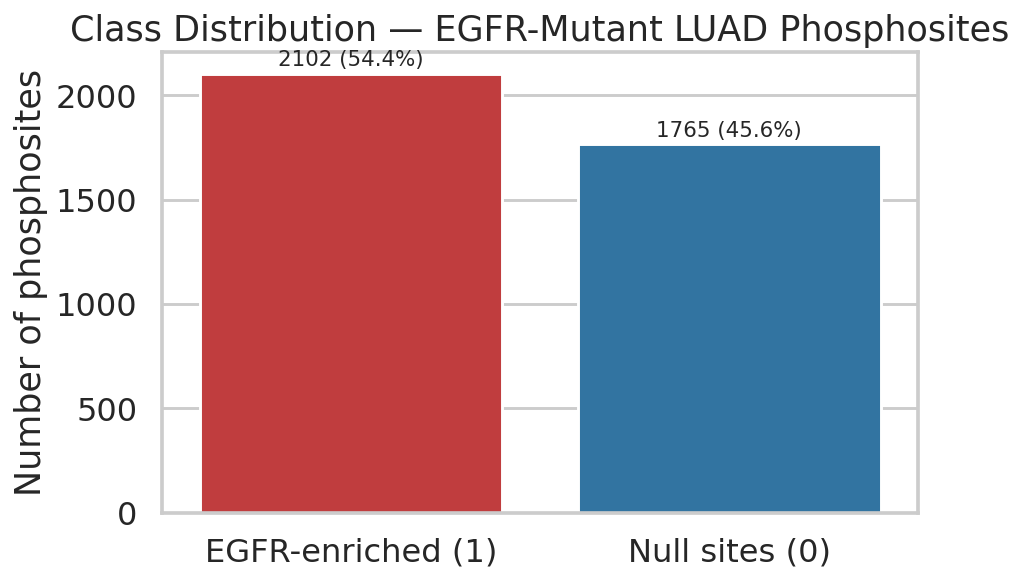

Saved: /home/saishyam/Protein_dynamics/Dynamic_properties/LUAD_diff_Phospho_EGFR_NAT/EGFR_UP_vs_Null_sites/Claude_Agent_Phospho_EGFR_NAT_LUAD/results_phospho_EGFR/01_class_distribution.png


In [5]:
# ── Class distribution ──────────────────────────────────────────────────────
class_counts = pd.DataFrame({
    "Class":  ["EGFR-enriched (1)", "Null sites (0)"],
    "Count": [len(egfr_clean), len(null_clean)]
})
class_counts["Fraction"] = class_counts["Count"] / class_counts["Count"].sum()

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.barplot(data=class_counts, x="Class", y="Count",
            palette=["#d62728", "#1f77b4"], ax=ax)
ax.set_title("Class Distribution — EGFR-Mutant LUAD Phosphosites")
ax.set_xlabel("")
ax.set_ylabel("Number of phosphosites")
for i, row in class_counts.iterrows():
    ax.text(i, row["Count"] * 1.01,
            f"{row['Count']} ({row['Fraction']:.1%})",
            ha="center", va="bottom", fontsize=11)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "01_class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {RESULTS_DIR / '01_class_distribution.png'}")

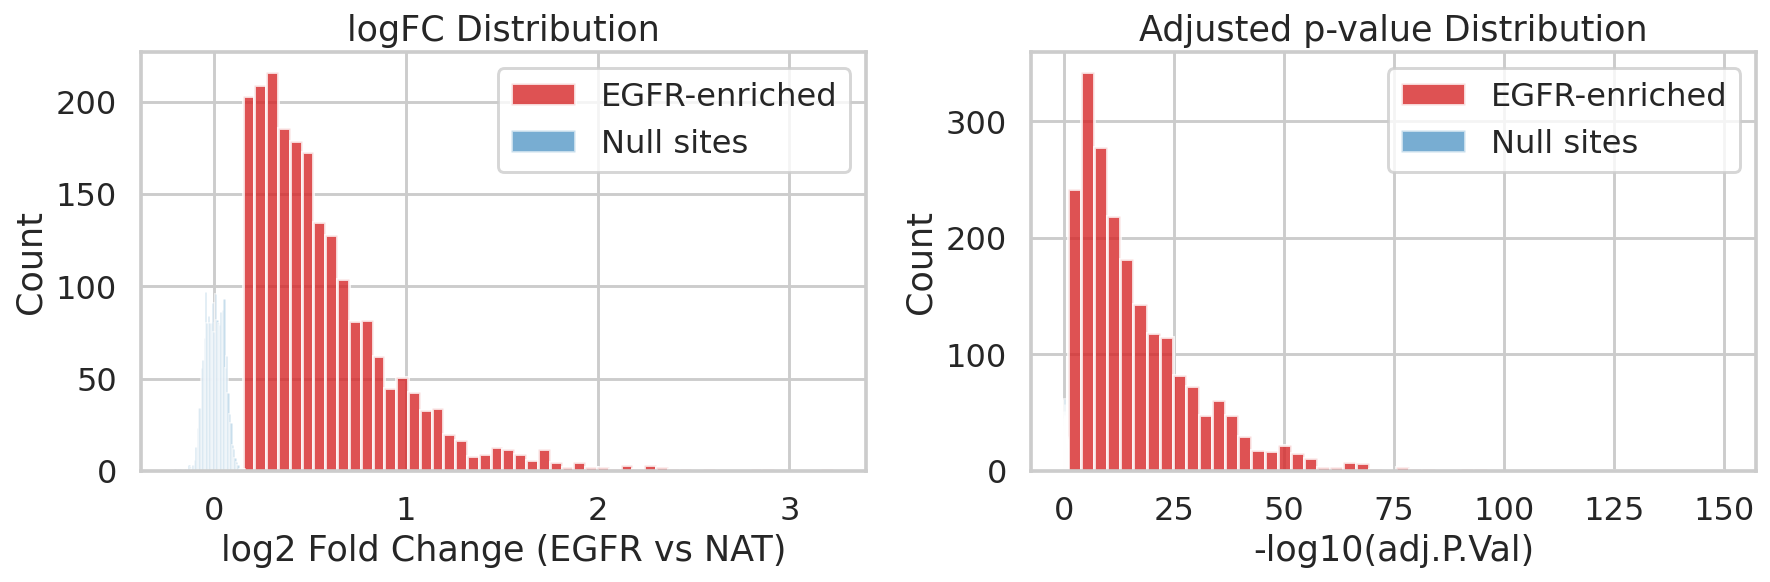

Saved: /home/saishyam/Protein_dynamics/Dynamic_properties/LUAD_diff_Phospho_EGFR_NAT/EGFR_UP_vs_Null_sites/Claude_Agent_Phospho_EGFR_NAT_LUAD/results_phospho_EGFR/02_logFC_pval_distributions.png


In [6]:
# ── logFC distribution comparison ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(egfr_clean["logFC"], bins=50, color="#d62728", alpha=0.8, label="EGFR-enriched")
axes[0].hist(null_clean["logFC"],  bins=50, color="#1f77b4", alpha=0.6, label="Null sites")
axes[0].set_xlabel("log2 Fold Change (EGFR vs NAT)")
axes[0].set_ylabel("Count")
axes[0].set_title("logFC Distribution")
axes[0].legend()

axes[1].hist(-np.log10(egfr_clean["adj.P.Val"].clip(lower=1e-160)), bins=50, color="#d62728", alpha=0.8, label="EGFR-enriched")
axes[1].hist(-np.log10(null_clean["adj.P.Val"].clip(lower=1e-160)),  bins=50, color="#1f77b4", alpha=0.6, label="Null sites")
axes[1].set_xlabel("-log10(adj.P.Val)")
axes[1].set_ylabel("Count")
axes[1].set_title("Adjusted p-value Distribution")
axes[1].legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / "02_logFC_pval_distributions.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {RESULTS_DIR / '02_logFC_pval_distributions.png'}")

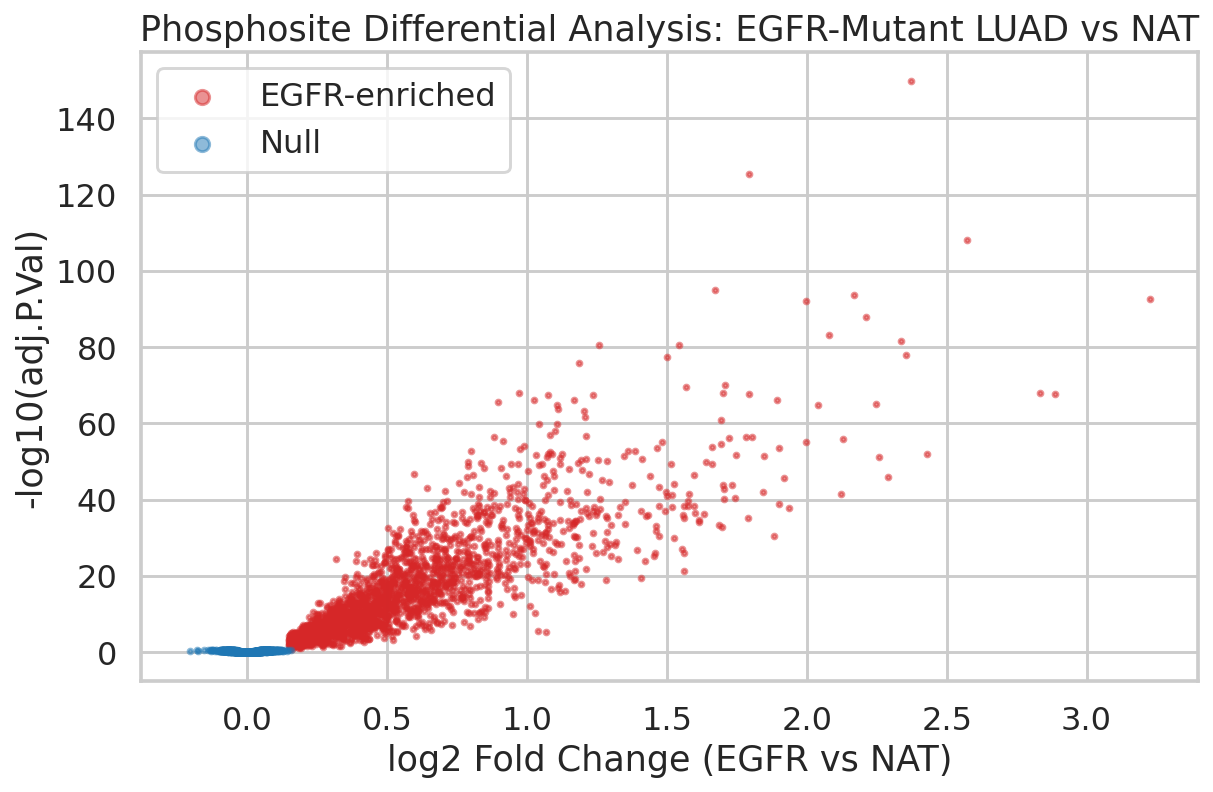

Saved: /home/saishyam/Protein_dynamics/Dynamic_properties/LUAD_diff_Phospho_EGFR_NAT/EGFR_UP_vs_Null_sites/Claude_Agent_Phospho_EGFR_NAT_LUAD/results_phospho_EGFR/03_scatter_logFC_vs_pval.png


In [7]:
# ── Volcano-style plot: logFC vs -log10(adj.P.Val) ───────────────────────────
combined_eda = pd.concat([
    egfr_clean.assign(group="EGFR-enriched"),
    null_clean.assign(group="Null")
], ignore_index=True)

fig, ax = plt.subplots(figsize=(9, 6))
palette = {"EGFR-enriched": "#d62728", "Null": "#1f77b4"}
for grp, sub in combined_eda.groupby("group"):
    ax.scatter(
        sub["logFC"],
        -np.log10(sub["adj.P.Val"].clip(lower=1e-160)),
        s=6, alpha=0.5, color=palette[grp], label=grp, rasterized=True
    )
ax.set_xlabel("log2 Fold Change (EGFR vs NAT)")
ax.set_ylabel("-log10(adj.P.Val)")
ax.set_title("Phosphosite Differential Analysis: EGFR-Mutant LUAD vs NAT")
ax.legend(markerscale=3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "03_scatter_logFC_vs_pval.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {RESULTS_DIR / '03_scatter_logFC_vs_pval.png'}")

In [8]:
# ── Central residue composition (position 7 of win15_seq = phosphosite) ─────
def central_residue(seq):
    if isinstance(seq, str) and len(seq) == 15:
        return seq[7].upper()
    return None

egfr_clean["central_aa"] = egfr_clean["win15_seq"].apply(central_residue)
null_clean["central_aa"]  = null_clean["win15_seq"].apply(central_residue)

for name, sub in [("EGFR-enriched", egfr_clean), ("Null", null_clean)]:
    counts = sub["central_aa"].value_counts()
    print(f"{name}: central residue counts")
    print(counts.to_string())
    print()

EGFR-enriched: central residue counts
central_aa
S    1715
T     190
P      24
Y      24
D      17
L      15
G      15
K      14
A      14
E      13
N      11
V      11
I      10
R       9
H       6
Q       5
W       4
F       3
C       1
M       1

Null: central residue counts
central_aa
S    1348
T     225
E      27
Y      24
P      19
K      16
L      16
A      15
R      12
G      11
V       9
D       9
H       8
N       6
I       6
M       5
W       3
Q       3
F       2
C       1



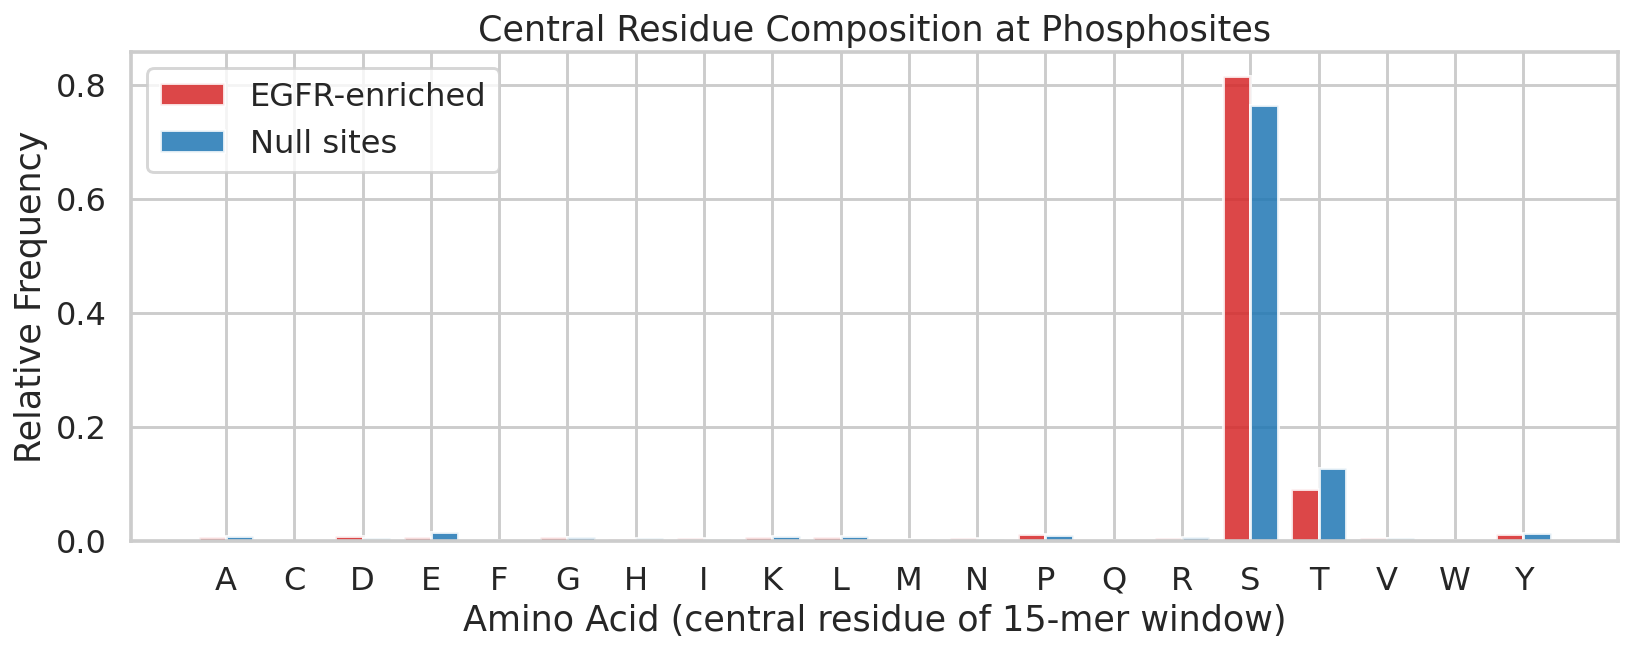

Saved: /home/saishyam/Protein_dynamics/Dynamic_properties/LUAD_diff_Phospho_EGFR_NAT/EGFR_UP_vs_Null_sites/Claude_Agent_Phospho_EGFR_NAT_LUAD/results_phospho_EGFR/04_central_residue_composition.png


In [9]:
# Bar chart: central residue frequency per class
aas = sorted(set(egfr_clean["central_aa"].dropna()) | set(null_clean["central_aa"].dropna()))

egfr_freq = egfr_clean["central_aa"].value_counts(normalize=True).reindex(aas, fill_value=0)
null_freq  = null_clean["central_aa"].value_counts(normalize=True).reindex(aas, fill_value=0)

x = np.arange(len(aas))
width = 0.4

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width/2, egfr_freq.values, width, label="EGFR-enriched", color="#d62728", alpha=0.85)
ax.bar(x + width/2, null_freq.values,  width, label="Null sites",    color="#1f77b4", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(aas)
ax.set_xlabel("Amino Acid (central residue of 15-mer window)")
ax.set_ylabel("Relative Frequency")
ax.set_title("Central Residue Composition at Phosphosites")
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "04_central_residue_composition.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {RESULTS_DIR / '04_central_residue_composition.png'}")

## Cell 5 — Ankh Protein Embedding

We embed **full protein sequences** with `ankh-base` (768-dim hidden states).  
Results are cached to `ankh_window_embeddings.npz` so re-runs skip the GPU step.

In [10]:
from transformers import AutoTokenizer, AutoModel

MODEL_NAME = "ElnaggarLab/ankh-base"
MAX_LEN    = 1024
BATCH_SIZE = 2

def sequence_to_id(seq: str) -> str:
    """Deterministic protein identifier from sequence (MD5)."""
    return hashlib.md5(seq.encode()).hexdigest()


def load_ankh_model():
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
    model = AutoModel.from_pretrained(MODEL_NAME, trust_remote_code=True).to(device).eval()
    embed_dim = model.config.hidden_size
    print(f"Ankh model loaded | hidden_size={embed_dim}")
    return tokenizer, model, embed_dim


@torch.no_grad()
def embed_proteins(df: pd.DataFrame, tokenizer, model) -> dict:
    """Embed unique sequences; return {protein_id: (L, D) tensor on CPU}."""
    emb_dict = {}
    unique_seqs = df["Sequence"].drop_duplicates().tolist()
    for i in tqdm(range(0, len(unique_seqs), BATCH_SIZE), desc="Embedding proteins"):
        batch_seqs = unique_seqs[i:i + BATCH_SIZE]
        pids = [sequence_to_id(s) for s in batch_seqs]

        tokens = tokenizer(
            batch_seqs,
            padding=True,
            truncation=True,
            max_length=MAX_LEN,
            return_tensors="pt",
        )
        input_ids     = tokens["input_ids"].to(device)
        attention_mask = tokens["attention_mask"].to(device)

        enc = model.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_hidden_states=True,
            return_dict=True,
        )
        hidden = enc.hidden_states[-1]   # (B, L, D)

        for j, pid in enumerate(pids):
            L = int(attention_mask[j].sum())
            emb_dict[pid] = hidden[j, :L].cpu()

    return emb_dict

In [24]:
# ── Load or compute protein embeddings ──────────────────────────────────────
all_proteins = pd.concat(
    [egfr_clean[["Sequence"]], null_clean[["Sequence"]]]
).drop_duplicates()
print(f"Unique proteins to embed: {len(all_proteins)}")

if EMBED_CACHE.exists():
    print(f"Loading cached embeddings from {EMBED_CACHE} …")
    cache_data = np.load(EMBED_CACHE, allow_pickle=True)
    protein_embeddings = cache_data["embeddings"].item()
    print(f"Loaded {len(protein_embeddings)} embeddings from cache.")
else:
    print("Cache not found — running Ankh embedding (this may take a while)…")
    t0 = time.time()
    tokenizer, ankh_model, EMBED_DIM = load_ankh_model()
    protein_embeddings = embed_proteins(all_proteins, tokenizer, ankh_model)
    elapsed = time.time() - t0
    print(f"Embedding complete in {elapsed:.1f}s | {len(protein_embeddings)} proteins")
    np.savez(EMBED_CACHE, embeddings=protein_embeddings)
    print(f"Embeddings cached to {EMBED_CACHE}")
    # Free GPU memory
    del ankh_model
    if device.type == "cuda":
        torch.cuda.empty_cache()

# Infer embedding dim from cache
EMBED_DIM = next(iter(protein_embeddings.values())).shape[1]
print(f"Embedding dim: {EMBED_DIM}")

Unique proteins to embed: 2304
Loading cached embeddings from /home/saishyam/Protein_dynamics/Dynamic_properties/LUAD_diff_Phospho_EGFR_NAT/EGFR_UP_vs_Null_sites/Claude_Agent_Phospho_EGFR_NAT_LUAD/ankh_window_embeddings.npz …


Loaded 2304 embeddings from cache.
Embedding dim: 768


## Cell 6 — 15-Residue Window Extraction

In [25]:
def build_window_dataset(df: pd.DataFrame, label: int, protein_embeddings: dict):
    """
    Slice the 15-residue context window around each phosphosite from
    the corresponding full-protein embedding.

    Returns:
        X  : np.ndarray of shape (N, 15, EMBED_DIM)
        y  : np.ndarray of shape (N,)
        kept : indices of rows that were successfully processed
    """
    X, y, kept = [], [], []
    skipped_missing_emb = 0
    skipped_boundary    = 0

    for idx, row in df.iterrows():
        if pd.isna(row["win15_start"]) or pd.isna(row["win15_end"]):
            continue

        pid = sequence_to_id(row["Sequence"])
        if pid not in protein_embeddings:
            skipped_missing_emb += 1
            continue

        emb = protein_embeddings[pid]    # (L, D)
        s   = int(row["win15_start"])
        e   = int(row["win15_end"])

        if e - s + 1 != 15:
            continue

        if e >= emb.shape[0]:
            skipped_boundary += 1
            continue

        X.append(emb[s:e + 1].numpy())   # (15, D)
        y.append(label)
        kept.append(idx)

    print(f"[label={label}] Extracted {len(X)} windows "
          f"| skipped: {skipped_missing_emb} (no emb), {skipped_boundary} (boundary)")
    return np.stack(X), np.array(y), kept


X_pos, y_pos, idx_pos = build_window_dataset(egfr_clean, 1, protein_embeddings)
X_neg, y_neg, idx_neg = build_window_dataset(null_clean,  0, protein_embeddings)

X = np.concatenate([X_pos, X_neg], axis=0).astype(np.float32)  # (N, 15, D)
y = np.concatenate([y_pos, y_neg], axis=0)                     # (N,)

print(f"\nCombined dataset : X={X.shape}, y={y.shape}")
print(f"Class balance    : {(y==1).sum()} positive / {(y==0).sum()} negative")

[label=1] Extracted 1798 windows | skipped: 0 (no emb), 304 (boundary)
[label=0] Extracted 1453 windows | skipped: 0 (no emb), 312 (boundary)

Combined dataset : X=(3251, 15, 768), y=(3251,)
Class balance    : 1798 positive / 1453 negative


## Cell 7 — Train / Test Split

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=SEED
)

print("Train set:")
print(f"  X_train : {X_train.shape}")
print(f"  Positive: {(y_train==1).sum()}  Negative: {(y_train==0).sum()}")
print(f"  Positive fraction: {(y_train==1).mean():.4f}")
print()
print("Test set:")
print(f"  X_test  : {X_test.shape}")
print(f"  Positive: {(y_test==1).sum()}  Negative: {(y_test==0).sum()}")
print(f"  Positive fraction: {(y_test==1).mean():.4f}")
print(f"  PR-AUC random baseline ≈ {(y_test==1).mean():.4f}")

Train set:
  X_train : (2600, 15, 768)
  Positive: 1438  Negative: 1162
  Positive fraction: 0.5531

Test set:
  X_test  : (651, 15, 768)
  Positive: 360  Negative: 291
  Positive fraction: 0.5530
  PR-AUC random baseline ≈ 0.5530


## Cell 8 — Model Definitions

Four architectures are compared:
| Model | Description |
|---|---|
| **MaxPool MLP** | Max-pools 15 residues → MLP |
| **AttentionPool MLP** | Learned attention weights over 15 residues → MLP |
| **CenterOnly MLP** | Uses only the phosphosite residue embedding → MLP |
| **Hybrid** | Concatenates center residue + attention-pooled context → MLP |

In [27]:
# ── Pooling modules ──────────────────────────────────────────────────────────

class MaxPool(nn.Module):
    def forward(self, x):
        # x: (B, 15, D)
        return x.max(dim=1).values


class AttentionPool(nn.Module):
    def __init__(self, dim: int):
        super().__init__()
        self.attn = nn.Linear(dim, 1)

    def forward(self, x):
        # x: (B, 15, D)
        scores  = self.attn(x).squeeze(-1)        # (B, 15)
        weights = F.softmax(scores, dim=1)        # (B, 15)
        return (x * weights.unsqueeze(-1)).sum(dim=1)  # (B, D)


# ── MLP classifier with a pluggable pooling head ─────────────────────────────

class PhosphoMLP(nn.Module):
    """Generic MLP with configurable pooling (MaxPool or AttentionPool)."""

    def __init__(self, pool: nn.Module, dim: int):
        super().__init__()
        self.pool = pool
        self.mlp = nn.Sequential(
            nn.Linear(dim, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1),
        )

    def forward(self, x):
        # x: (B, 15, D)
        return self.mlp(self.pool(x)).squeeze(-1)


# ── Center-only MLP ───────────────────────────────────────────────────────────

class CenterOnlyMLP(nn.Module):
    """Uses only the central residue (index 7) of the 15-mer."""

    def __init__(self, dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1),
        )

    def forward(self, x):
        # x: (B, 15, D)  →  take center residue
        return self.net(x[:, 7, :]).squeeze(-1)


# ── Hybrid: Center + Attention-pooled context ─────────────────────────────────

class HybridMLP(nn.Module):
    """Concatenates the center residue with an attention-pooled context vector."""

    def __init__(self, dim: int):
        super().__init__()
        self.attn_pool = AttentionPool(dim)
        self.classifier = nn.Sequential(
            nn.Linear(dim * 2, 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1),
        )

    def forward(self, x):
        # x: (B, 15, D)
        center  = x[:, 7, :]               # (B, D)
        context = self.attn_pool(x)        # (B, D)
        return self.classifier(
            torch.cat([center, context], dim=1)  # (B, 2D)
        ).squeeze(-1)


print("All model classes defined.")

All model classes defined.


## Cell 9 — Training Loop

In [28]:
def train_and_eval(
    model: nn.Module,
    X_tr: np.ndarray, y_tr: np.ndarray,
    X_va: np.ndarray, y_va: np.ndarray,
    epochs: int = 20,
    lr: float = 1e-3,
    batch_size: int = 64,
) -> tuple:
    """
    Train model with class-weighted BCEWithLogitsLoss.
    Returns (probs, roc_auc, pr_auc).
    """
    model = model.to(device)

    pos_weight = torch.tensor(
        (y_tr == 0).sum() / (y_tr == 1).sum(),
        dtype=torch.float32,
    ).to(device)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

    loader = DataLoader(
        TensorDataset(
            torch.tensor(X_tr, dtype=torch.float32),
            torch.tensor(y_tr, dtype=torch.float32),
        ),
        batch_size=batch_size,
        shuffle=True,
    )

    val_X = torch.tensor(X_va, dtype=torch.float32).to(device)

    for ep in range(epochs):
        model.train()
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            criterion(model(xb), yb).backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(model(val_X)).cpu().numpy()

    roc = roc_auc_score(y_va, probs)
    pr  = average_precision_score(y_va, probs)
    return probs, roc, pr


print("Training helper defined.")

Training helper defined.


In [29]:
D = EMBED_DIM

# Instantiate all models
models_to_train = {
    "MaxPool MLP":      PhosphoMLP(MaxPool(),       dim=D),
    "AttnPool MLP":     PhosphoMLP(AttentionPool(D), dim=D),
    "CenterOnly MLP":   CenterOnlyMLP(dim=D),
    "Hybrid (C+Attn)": HybridMLP(dim=D),
}

results = {}  # name -> {probs, roc_auc, pr_auc}

for name, model in models_to_train.items():
    print(f"Training: {name} …", end=" ", flush=True)
    t0 = time.time()
    probs, roc, pr = train_and_eval(
        model, X_train, y_train, X_test, y_test, epochs=20
    )
    elapsed = time.time() - t0
    results[name] = {"probs": probs, "roc_auc": roc, "pr_auc": pr}
    print(f"AUROC={roc:.4f}  AUPRC={pr:.4f}  [{elapsed:.1f}s]")

print("\nAll models trained.")

Training: MaxPool MLP … 

AUROC=0.5801  AUPRC=0.6445  [1.8s]
Training: AttnPool MLP … AUROC=0.5773  AUPRC=0.6387  [2.0s]
Training: CenterOnly MLP … AUROC=0.6003  AUPRC=0.6416  [1.8s]
Training: Hybrid (C+Attn) … AUROC=0.6164  AUPRC=0.6474  [2.0s]

All models trained.


## Cell 10 — ROC & Precision-Recall Curves (All Models)

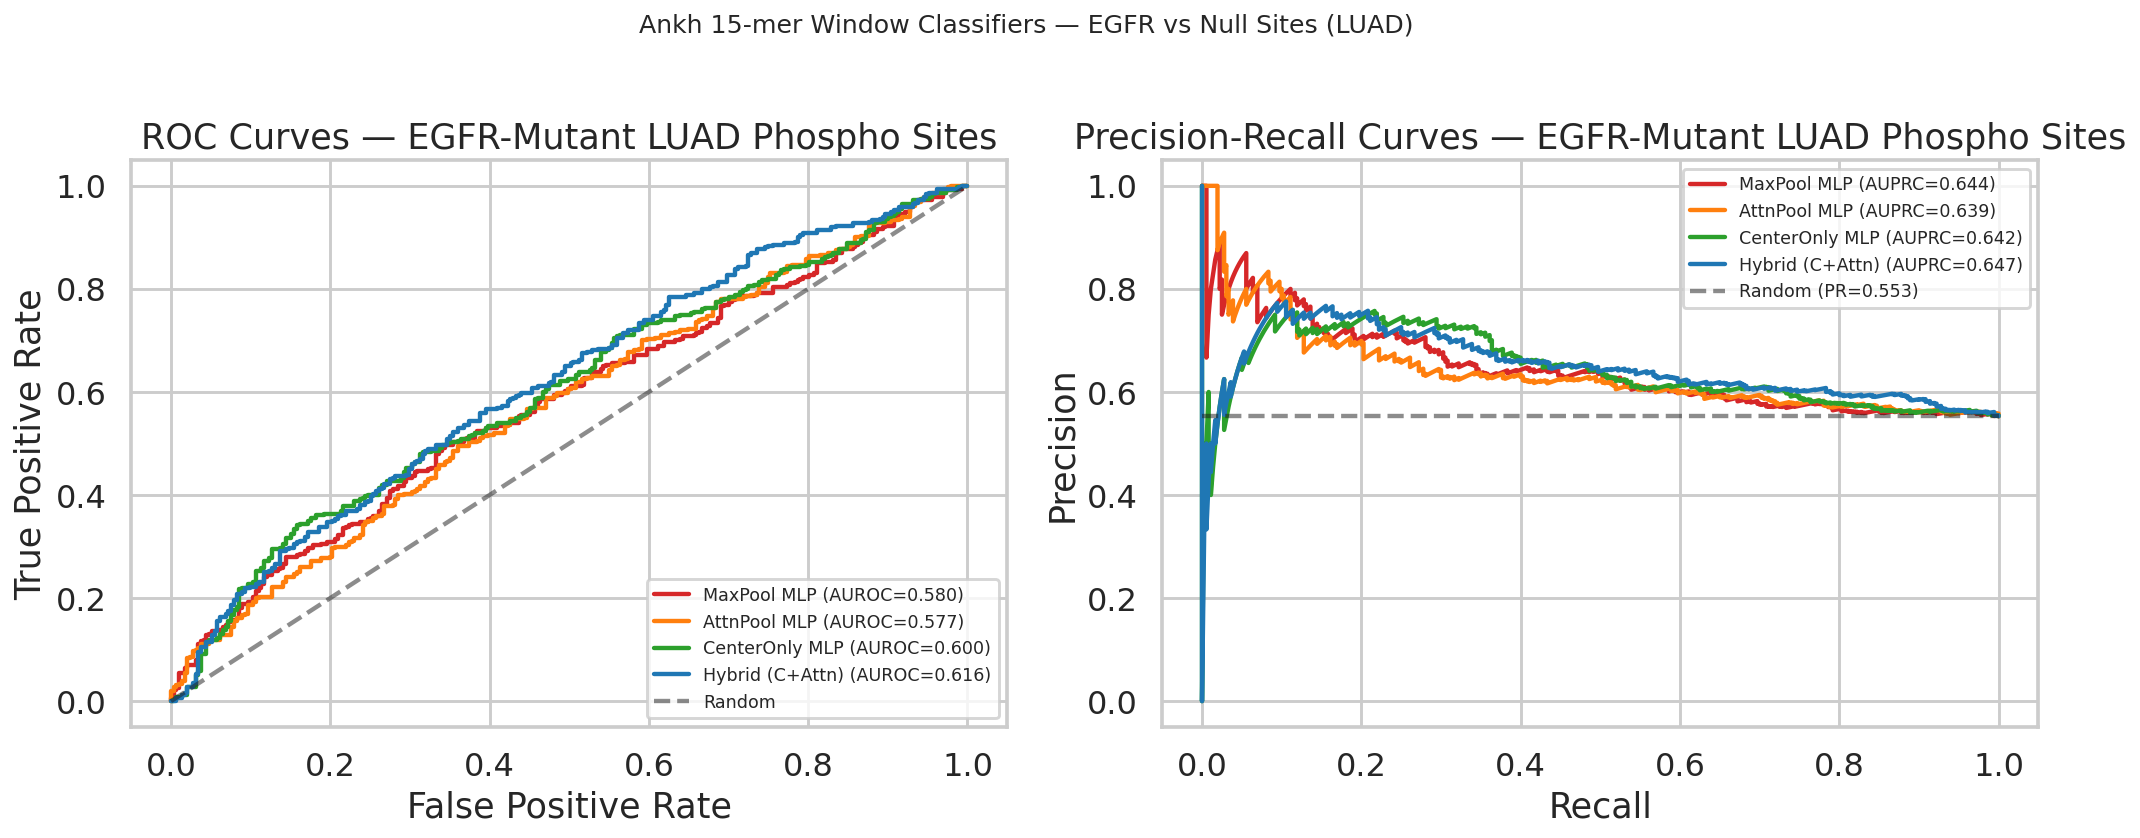

Saved: /home/saishyam/Protein_dynamics/Dynamic_properties/LUAD_diff_Phospho_EGFR_NAT/EGFR_UP_vs_Null_sites/Claude_Agent_Phospho_EGFR_NAT_LUAD/results_phospho_EGFR/05_roc_pr_curves.png


In [30]:
PALETTE = ["#d62728", "#ff7f0e", "#2ca02c", "#1f77b4"]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

baseline_pr = (y_test == 1).mean()

for (name, res), color in zip(results.items(), PALETTE):
    probs = res["probs"]

    # ROC
    fpr, tpr, _ = roc_curve(y_test, probs)
    axes[0].plot(fpr, tpr, label=f"{name} (AUROC={res['roc_auc']:.3f})", color=color)

    # PR
    prec, rec, _ = precision_recall_curve(y_test, probs)
    axes[1].plot(rec, prec, label=f"{name} (AUPRC={res['pr_auc']:.3f})", color=color)

axes[0].plot([0, 1], [0, 1], "k--", alpha=0.5, label="Random")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves — EGFR-Mutant LUAD Phospho Sites")
axes[0].legend(loc="lower right", fontsize=9)

axes[1].hlines(baseline_pr, 0, 1, linestyles="--", colors="k", alpha=0.5,
               label=f"Random (PR={baseline_pr:.3f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curves — EGFR-Mutant LUAD Phospho Sites")
axes[1].legend(loc="upper right", fontsize=9)

plt.suptitle("Ankh 15-mer Window Classifiers — EGFR vs Null Sites (LUAD)",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "05_roc_pr_curves.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {RESULTS_DIR / '05_roc_pr_curves.png'}")

## Cell 11 — Detailed Metrics & Confusion Matrices

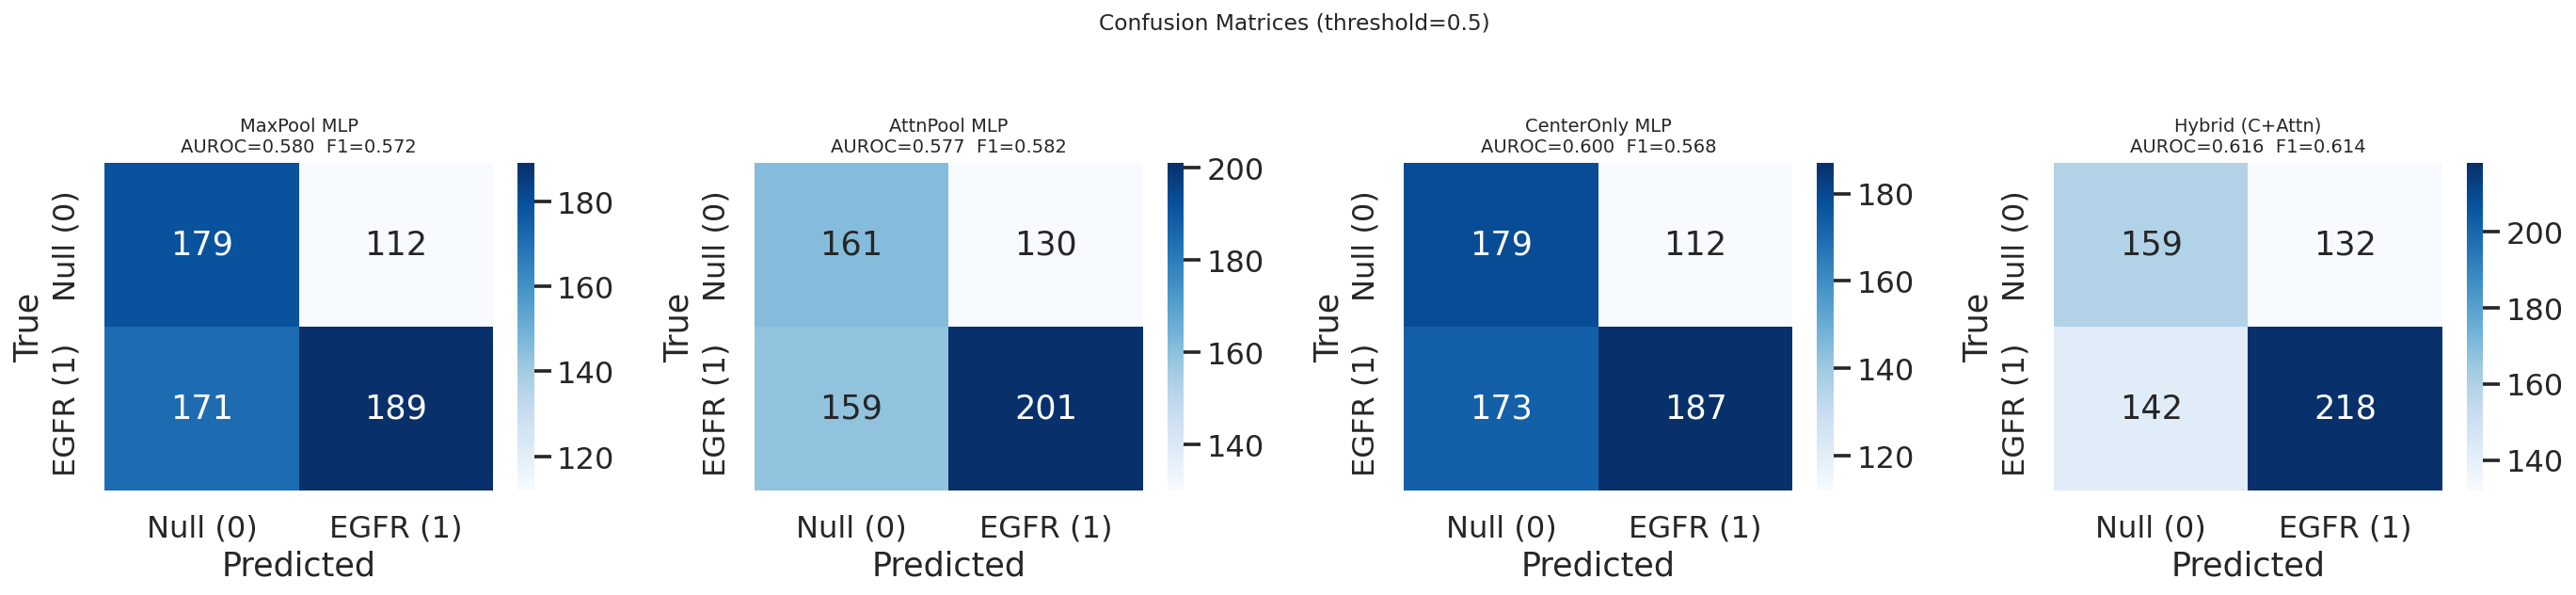

Saved: /home/saishyam/Protein_dynamics/Dynamic_properties/LUAD_diff_Phospho_EGFR_NAT/EGFR_UP_vs_Null_sites/Claude_Agent_Phospho_EGFR_NAT_LUAD/results_phospho_EGFR/06_confusion_matrices.png


In [31]:
THRESHOLD = 0.5

metrics_rows = []
fig, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 4.5))
if len(results) == 1:
    axes = [axes]

for ax, (name, res) in zip(axes, results.items()):
    probs = res["probs"]
    preds = (probs >= THRESHOLD).astype(int)

    prec   = precision_score(y_test, preds, zero_division=0)
    rec    = recall_score(y_test, preds, zero_division=0)
    f1     = f1_score(y_test, preds, zero_division=0)
    roc    = res["roc_auc"]
    pr_auc = res["pr_auc"]

    metrics_rows.append({
        "Model":    name,
        "AUROC":    round(roc, 4),
        "AUPRC":    round(pr_auc, 4),
        "Precision": round(prec, 4),
        "Recall":   round(rec, 4),
        "F1":       round(f1, 4),
    })

    # Confusion matrix
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", ax=ax,
        xticklabels=["Null (0)", "EGFR (1)"],
        yticklabels=["Null (0)", "EGFR (1)"],
    )
    ax.set_title(f"{name}\nAUROC={roc:.3f}  F1={f1:.3f}", fontsize=10)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.suptitle("Confusion Matrices (threshold=0.5)", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "06_confusion_matrices.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {RESULTS_DIR / '06_confusion_matrices.png'}")

In [32]:
metrics_df = pd.DataFrame(metrics_rows).sort_values("AUROC", ascending=False).reset_index(drop=True)
print("=== Model Performance Summary ===")
display(metrics_df)

metrics_df.to_csv(RESULTS_DIR / "07_model_metrics_summary.csv", index=False)
print(f"\nSaved: {RESULTS_DIR / '07_model_metrics_summary.csv'}")

=== Model Performance Summary ===


,Model,AUROC,AUPRC,Precision,Recall,F1
0,Hybrid (C+Attn),0.6164,0.6474,0.6229,0.6056,0.6141
1,CenterOnly MLP,0.6003,0.6416,0.6254,0.5194,0.5675
2,MaxPool MLP,0.5801,0.6445,0.6279,0.5250,0.5719
3,AttnPool MLP,0.5773,0.6387,0.6073,0.5583,0.5818



Saved: /home/saishyam/Protein_dynamics/Dynamic_properties/LUAD_diff_Phospho_EGFR_NAT/EGFR_UP_vs_Null_sites/Claude_Agent_Phospho_EGFR_NAT_LUAD/results_phospho_EGFR/07_model_metrics_summary.csv


## Cell 12 — Embedding Visualisation (PCA + t-SNE)

In [33]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Pool window embeddings to (N, D) for visualisation
X_mean_pool = X.mean(axis=1)   # (N, D)

# PCA: reduce to 50 dims first for efficiency
pca = PCA(n_components=50, random_state=SEED)
X_pca50 = pca.fit_transform(X_mean_pool)
print(f"PCA 50-component variance explained: {pca.explained_variance_ratio_.sum():.2%}")

# 2D PCA for quick scatter
X_pca2 = X_pca50[:, :2]

# t-SNE on 50-dim PCA
print("Running t-SNE … (may take ~30s)")
tsne = TSNE(n_components=2, perplexity=40, random_state=SEED, n_iter=1000)
X_tsne = tsne.fit_transform(X_pca50)
print("t-SNE done.")

PCA 50-component variance explained: 81.54%
Running t-SNE … (may take ~30s)


/home/saishyam/ankh_env/lib64/python3.9/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


t-SNE done.


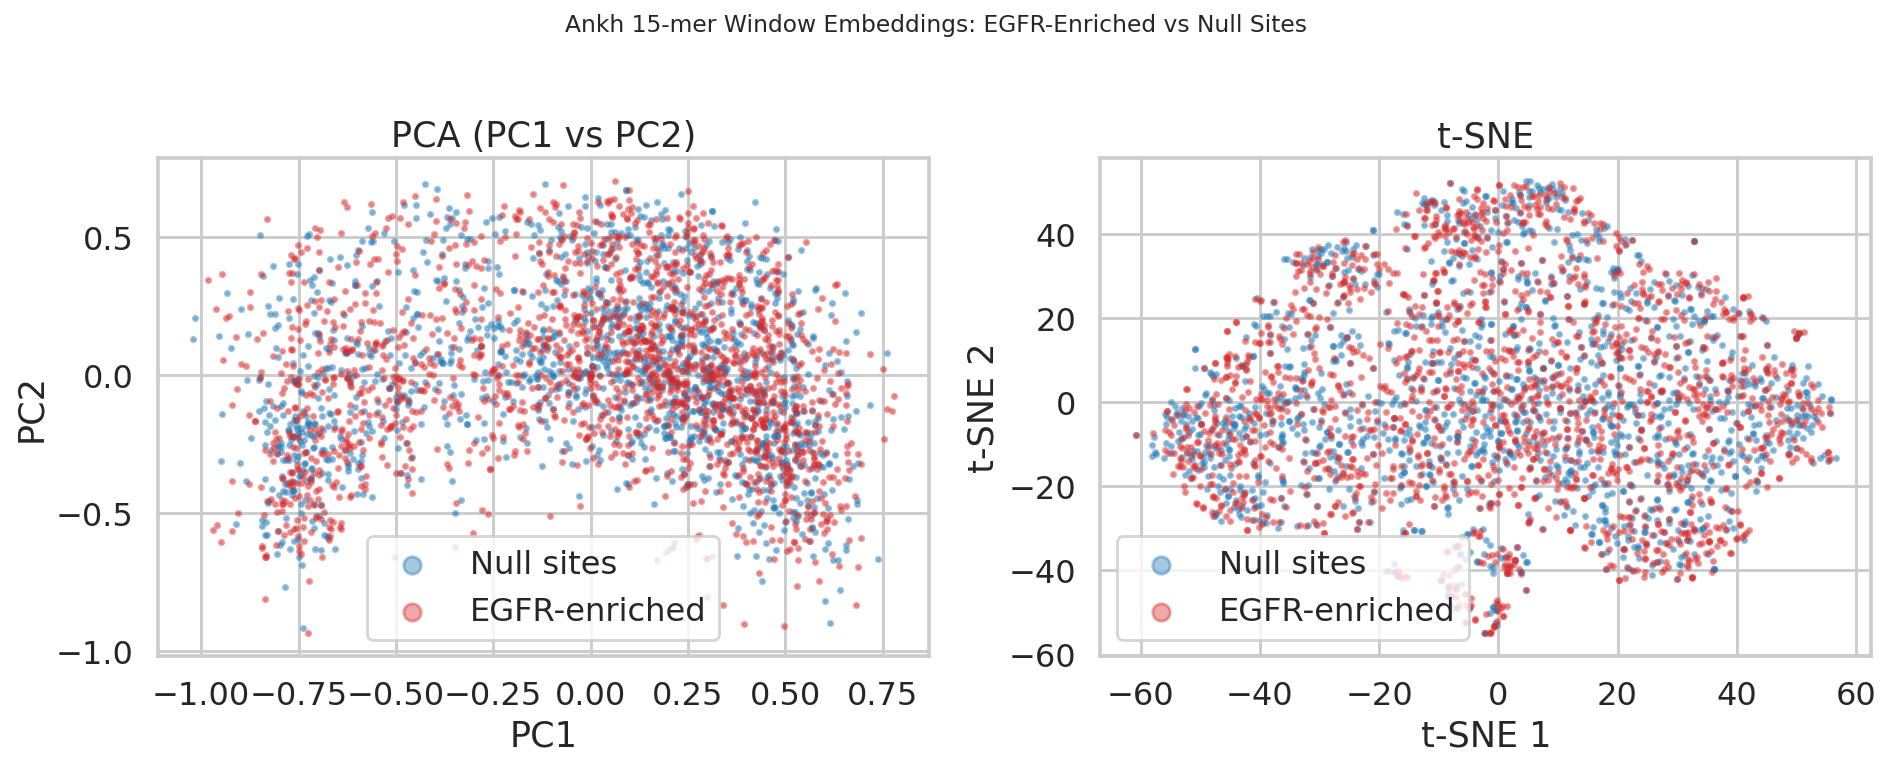

Saved: /home/saishyam/Protein_dynamics/Dynamic_properties/LUAD_diff_Phospho_EGFR_NAT/EGFR_UP_vs_Null_sites/Claude_Agent_Phospho_EGFR_NAT_LUAD/results_phospho_EGFR/08_pca_tsne.png


In [34]:
label_colors = {1: "#d62728", 0: "#1f77b4"}
label_names  = {1: "EGFR-enriched", 0: "Null sites"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for label in [0, 1]:
    mask = y == label
    axes[0].scatter(
        X_pca2[mask, 0], X_pca2[mask, 1],
        s=5, alpha=0.4, color=label_colors[label],
        label=label_names[label], rasterized=True
    )
    axes[1].scatter(
        X_tsne[mask, 0], X_tsne[mask, 1],
        s=5, alpha=0.4, color=label_colors[label],
        label=label_names[label], rasterized=True
    )

axes[0].set_title("PCA (PC1 vs PC2)")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].legend(markerscale=4)

axes[1].set_title("t-SNE")
axes[1].set_xlabel("t-SNE 1")
axes[1].set_ylabel("t-SNE 2")
axes[1].legend(markerscale=4)

plt.suptitle("Ankh 15-mer Window Embeddings: EGFR-Enriched vs Null Sites",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "08_pca_tsne.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {RESULTS_DIR / '08_pca_tsne.png'}")

## Cell 13 — HTML Summary Report

In [35]:
import base64


def img_to_b64(path: Path) -> str:
    """Convert a PNG to an inline base64 HTML img tag."""
    with open(path, "rb") as f:
        data = base64.b64encode(f.read()).decode("utf-8")
    return f'<img src="data:image/png;base64,{data}" style="max-width:100%;"/>'


plot_files = sorted(RESULTS_DIR.glob("*.png"))

metrics_html = metrics_df.to_html(index=False, border=1,
                                   classes="metrics", justify="center")

html_parts = [
    """<!DOCTYPE html>
<html><head>
<meta charset='utf-8'/>
<title>Ankh Phospho EGFR LUAD — Analysis Report</title>
<style>
  body { font-family: Arial, sans-serif; max-width: 1100px; margin: auto; padding: 20px; }
  h1   { color: #b22222; }
  h2   { color: #2c3e50; border-bottom: 2px solid #ccc; padding-bottom: 4px; }
  table.metrics { border-collapse: collapse; width: 100%; }
  table.metrics th, table.metrics td { border: 1px solid #aaa; padding: 8px 14px; text-align: center; }
  table.metrics th { background-color: #2c3e50; color: white; }
  .plot-grid { display: flex; flex-wrap: wrap; gap: 16px; }
  .plot-grid figure { margin: 0; text-align: center; }
</style>
</head><body>
<h1>Ankh Differential Phosphorylation Classifier</h1>
<h2>Dataset: EGFR-Mutant LUAD vs Normal Adjacent Tissue (NAT)</h2>
<p><b>EGFR-enriched sites:</b> 2 189 &nbsp;|&nbsp; <b>Null sites:</b> 1 844</p>
<p><b>Model:</b> Ankh-base (768-dim) 15-residue context window around phosphosite</p>
<hr/>
<h2>Model Performance Summary</h2>
""",
    metrics_html,
    "<hr/>\n<h2>Plots</h2>\n<div class='plot-grid'>\n",
]

for p in plot_files:
    html_parts.append(f"<figure>{img_to_b64(p)}<figcaption>{p.name}</figcaption></figure>\n")

html_parts.append("</div></body></html>")

report_path = RESULTS_DIR / "report_phospho_egfr_luad.html"
report_path.write_text("".join(html_parts), encoding="utf-8")
print(f"HTML report saved: {report_path}")

HTML report saved: /home/saishyam/Protein_dynamics/Dynamic_properties/LUAD_diff_Phospho_EGFR_NAT/EGFR_UP_vs_Null_sites/Claude_Agent_Phospho_EGFR_NAT_LUAD/results_phospho_EGFR/report_phospho_egfr_luad.html


## Cell 14 — Final Summary

In [ ]:

print("=" * 60)
print("FINAL RESULTS SUMMARY")
print("=" * 60)
print(f"Dataset  : EGFR-mutant LUAD differential phosphoproteomics")
print(f"Positive : EGFR-enriched sites  ({(y==1).sum()} samples)")
print(f"Negative : Null sites           ({(y==0).sum()} samples)")
print(f"Embedder : Ankh-base, 768 dim, 15-residue window")
print(f"Split    : 80% train / 20% test, stratified")
print()

# Random baseline stats
random_auroc  = 0.5
random_prauc  = (y_test == 1).mean()
print("Random baselines (test set):")
print(f"  AUROC (random classifier) = {random_auroc:.4f}")
print(f"  PR-AUC (random classifier) = {random_prauc:.4f}  "
      f"[= positive class fraction = {(y_test==1).sum()}/{len(y_test)}]")
print()

print("Model Results vs Random Baseline:")
print(f"{'Model':<20} {'AUROC':>7} {'vs_rand':>9} {'AUPRC':>7} {'vs_rand':>9} {'F1':>7}")
print("-" * 65)
for _, row in metrics_df.iterrows():
    auroc_gain = row["AUROC"] - random_auroc
    prauc_gain = row["AUPRC"] - random_prauc
    print(f"{row['Model']:<20} {row['AUROC']:>7.4f} {auroc_gain:>+9.4f} "
          f"{row['AUPRC']:>7.4f} {prauc_gain:>+9.4f} {row['F1']:>7.4f}")
print()

best = metrics_df.iloc[0]
print(f"Best model : {best['Model']}")
print(f"  AUROC  = {best['AUROC']:.4f}  (random = {random_auroc:.4f}, "
      f"gain = {best['AUROC'] - random_auroc:+.4f})")
print(f"  PR-AUC = {best['AUPRC']:.4f}  (random = {random_prauc:.4f}, "
      f"gain = {best['AUPRC'] - random_prauc:+.4f})")
print(f"  F1     = {best['F1']:.4f}")
print()
print("All outputs saved to:", RESULTS_DIR.resolve())
for f in sorted(RESULTS_DIR.iterdir()):
    print(f"  {f.name}")


FINAL RESULTS SUMMARY
Dataset  : EGFR-mutant LUAD differential phosphoproteomics
Positive : EGFR-enriched sites  (1798 samples)
Negative : Null sites           (1453 samples)
Embedder : Ankh-base, 768 dim, 15-residue window
Split    : 80% train / 20% test, stratified

          Model  AUROC  AUPRC  Precision  Recall     F1
Hybrid (C+Attn) 0.6164 0.6474     0.6229  0.6056 0.6141
 CenterOnly MLP 0.6003 0.6416     0.6254  0.5194 0.5675
    MaxPool MLP 0.5801 0.6445     0.6279  0.5250 0.5719
   AttnPool MLP 0.5773 0.6387     0.6073  0.5583 0.5818

Best model: Hybrid (C+Attn)
  AUROC = 0.6164
  AUPRC = 0.6474
  F1    = 0.6141

All outputs saved to: /home/saishyam/Protein_dynamics/Dynamic_properties/LUAD_diff_Phospho_EGFR_NAT/EGFR_UP_vs_Null_sites/Claude_Agent_Phospho_EGFR_NAT_LUAD/results_phospho_EGFR
  01_class_distribution.png
  02_logFC_pval_distributions.png
  03_scatter_logFC_vs_pval.png
  04_central_residue_composition.png
  05_roc_pr_curves.png
  06_confusion_matrices.png
  07_model_